AR(1) Observation Process

In [ ]:
!pip uninstall tensorflow

In [ ]:
!pip install tensorflow-gpu==2.0.0-alpha0

     |████████████████████████████████| 332.1MB 46kB/s 
     |████████████████████████████████| 3.0MB 59.5MB/s 
     |████████████████████████████████| 419kB 73.8MB/s 


In [ ]:
import tensorflow as tf
print(tf.__version__)

2.0.0-alpha0


In [ ]:
from __future__ import absolute_import, division, print_function, unicode_literals

import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.layers import Input, LSTM, Dense, Reshape

In [ ]:
input_dim = 1 # input dimensionality
mu_pre = np.array([0])
lambda_pre = np.array([-0.3])
mu_post = np.array([1])
lambda_post = np.array([0.2])

In [ ]:
batch_size = 32
num_batch = 100
data_size = batch_size * num_batch
timesteps = 2000
rho = 0.001

x_train = []
y_train = []
for jj in range(data_size):
    tau = np.random.geometric(rho) # random change-point
    t = 0
    data_i = np.zeros([1,timesteps,input_dim]) 
    label_i = np.zeros([1,timesteps,1])  
    while t < timesteps:
        if t > 0 and t < tau:
            data_i[0][t] = mu_pre + lambda_pre*data_i[0][t-1] + np.random.randn()  
            label_i[0][t] = 0.0  # pre-label   
        elif t >= tau:
            data_i[0][t] = mu_post + lambda_post*data_i[0][t-1] + np.random.randn()    
            label_i[0][t] = 1.0  # post-label  
        t += 1

    if x_train == []:
        x_train = data_i
    else:    
        x_train = np.concatenate((x_train,data_i),axis=0)

    if y_train == []:
        y_train = label_i 
    else:
        y_train = np.concatenate((y_train,label_i),axis=0)

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:23: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:28: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.


In [ ]:
print(x_train.shape)
print(y_train.shape)

(3200, 2000, 1)
(3200, 2000, 1)


In [ ]:
val_size = 500
timesteps = 2000

x_val = []
y_val = []
for jj in range(val_size):
    tau = timesteps//2 # fixed change-point
    t = 0
    data_i = np.zeros([1,timesteps,input_dim]) 
    label_i = np.zeros([1,timesteps,1])  
    while t < timesteps:
        if t > 0 and t < tau:
            data_i[0][t] = mu_pre + lambda_pre*data_i[0][t-1] + np.random.randn()  
            label_i[0][t] = 0.0  # pre-label   
        elif t >= tau:
            data_i[0][t] = mu_post + lambda_post*data_i[0][t-1] + np.random.randn()    
            label_i[0][t] = 1.0  # post-label  
        t += 1

    if x_val == []:
        x_val = data_i
    else:    
        x_val = np.concatenate((x_val,data_i),axis=0)

    if y_val == []:
        y_val = label_i 
    else:
        y_val = np.concatenate((y_val,label_i),axis=0)

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:20: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:25: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.


In [ ]:
print(x_val.shape)
print(y_val.shape)

(500, 2000, 1)
(500, 2000, 1)


In [ ]:
model = tf.keras.Sequential() 
model.add(Input(shape=(timesteps,input_dim))) 
model.add(LSTM(16, return_sequences = True))  
model.add(Dense(10, activation='relu')) 
model.add(Dense(1, activation='sigmoid'))
model.summary() 

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
unified_lstm (UnifiedLSTM)   (None, 2000, 16)          1152      
_________________________________________________________________
dense (Dense)                (None, 2000, 10)          170       
_________________________________________________________________
dense_1 (Dense)              (None, 2000, 1)           11        
Total params: 1,333
Trainable params: 1,333
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train,
          validation_data=(x_val, y_val),
          batch_size=batch_size,
          epochs=20)

Train on 3200 samples, validate on 500 samples
Epoch 1/20
3200/3200 [==============================] - 13s 4ms/sample - loss: 0.4053 - accuracy: 0.9319 - val_loss: 0.1157 - val_accuracy: 0.9877
Epoch 2/20
3200/3200 [==============================] - 7s 2ms/sample - loss: 0.0495 - accuracy: 0.9944 - val_loss: 0.0285 - val_accuracy: 0.9951
Epoch 3/20
3200/3200 [==============================] - 7s 2ms/sample - loss: 0.0215 - accuracy: 0.9961 - val_loss: 0.0202 - val_accuracy: 0.9959
Epoch 4/20
3200/3200 [==============================] - 7s 2ms/sample - loss: 0.0170 - accuracy: 0.9965 - val_loss: 0.0176 - val_accuracy: 0.9962
Epoch 5/20
3200/3200 [==============================] - 7s 2ms/sample - loss: 0.0153 - accuracy: 0.9966 - val_loss: 0.0165 - val_accuracy: 0.9964
Epoch 6/20
3200/3200 [==============================] - 7s 2ms/sample - loss: 0.0145 - accuracy: 0.9968 - val_loss: 0.0158 - val_accuracy: 0.9965
Epoch 7/20
3200/3200 [==============================] - 7s 2ms/sample - loss

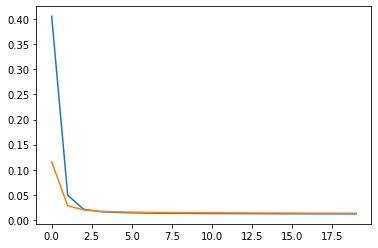

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [ ]:
model2 = tf.keras.Sequential()  # model2 has the same structure and weights with the trained network  
model2.add(Input(shape=(1,input_dim), batch_size=1)) # only difference is it takes single input a time, as usual in online stream processing
model2.add(LSTM(16, return_sequences = True, stateful=True))  # we have an explicit control on the internal RNN state: the RNN state is going to be reset for each new data stream       
model2.add(Dense(10, activation='relu')) 
model2.add(Dense(1, activation='sigmoid')) 
model2.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
unified_lstm_1 (UnifiedLSTM) (1, 1, 16)                1152      
_________________________________________________________________
dense_2 (Dense)              (1, 1, 10)                170       
_________________________________________________________________
dense_3 (Dense)              (1, 1, 1)                 11        
Total params: 1,333
Trainable params: 1,333
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model2.set_weights(model.get_weights()) 

**Performance Evaluation** **(Online Detection Phase)**

1) Bayesian Setting

In [ ]:
# Performance Evaluation (Data-Driven QCD Procedure & Modified Shiryaev Algorithm) 
test_size = 5000 # number of experiments  
h_vec = np.append(np.linspace(0.01,0.99,50),0.995) # test thresholds
num_false_alarm_events = np.zeros(len(h_vec)) # number of false alarm events at each threshold over all experiments for the data-driven procedure
total_det_delays = np.zeros(len(h_vec)) # sum of all detection delays at each threshold over all experiments for the data-driven procedure
shiryaev_false_alarm_events = np.zeros(len(h_vec)) # same for the Shiryaev algorithm
shiryaev_det_delays = np.zeros(len(h_vec))
for jj in range(test_size):
    if jj % 200 == 0:
        print(jj)
    # initialization for a new experiment
    t = 0 # time  
    data_prev = 0 # initialization for the data seen at time t-1
    tau = np.random.geometric(rho) # random change-point
    model2.reset_states() # reset the internal RNN state for the new experiment
    alarm_flag_vec = np.zeros(len(h_vec)) # alarm flags
    shiryaev_flag_vec = np.zeros(len(h_vec)) 
    p = 0 # reset the Shiryaev state 
    # new experiment
    while alarm_flag_vec[-1] == 0 or shiryaev_flag_vec[-1] == 0:
        t += 1
        # observation at time t
        if t < tau:
            data_t = mu_pre + lambda_pre*data_prev + np.random.randn(1,1,input_dim)
        else:
            data_t = mu_post + lambda_post*data_prev + np.random.randn(1,1,input_dim)
        # decision statistic of the data-driven procedure
        dec_stat = model2.predict(data_t) 
        dec_stat = dec_stat[0][0][0]
        # Shiryaev algorithm: update the state and the decision statistic
        data_t = data_t[0][0]
        p_til = p + (1-p)*rho
        LR = np.exp((data_t - 0.5*(data_prev*(lambda_pre+lambda_post) + (mu_pre+mu_post)))*(data_prev*(lambda_post-lambda_pre) + (mu_post-mu_pre))) # likelihood ratio
        p = (p_til*LR)/(p_til*LR + (1-p_til)) 
        # update the alarm flags, the false alarm events, and the detection delays
        if t < tau:
            # data-driven procedure
            num_false_alarm_events += (alarm_flag_vec == 0)*(dec_stat >= h_vec)
            alarm_flag_vec += (alarm_flag_vec == 0)*(dec_stat >= h_vec) 
            # Shiryaev algorithm
            shiryaev_false_alarm_events += (shiryaev_flag_vec == 0)*(p >= h_vec)
            shiryaev_flag_vec += (shiryaev_flag_vec == 0)*(p >= h_vec) 
        else:
            # data-driven procedure
            total_det_delays += (t-tau)*(alarm_flag_vec == 0)*(dec_stat >= h_vec)
            alarm_flag_vec += (alarm_flag_vec == 0)*(dec_stat >= h_vec)
            # Shiryaev algorithm
            shiryaev_det_delays += (t-tau)*(shiryaev_flag_vec == 0)*(p >= h_vec)
            shiryaev_flag_vec += (shiryaev_flag_vec == 0)*(p >= h_vec)
        # update the previous time data
        data_prev = data_t

# compute the probability of false alarm (pfa) and average detection delay (add) over all experiments
pfa_vec = num_false_alarm_events/test_size
add_vec = total_det_delays/test_size
shiryaev_pfa_vec = shiryaev_false_alarm_events/test_size
shiryaev_add_vec = shiryaev_det_delays/test_size

In [ ]:
pfa_vec 

array([0.999 , 0.999 , 0.999 , 0.9988, 0.9968, 0.988 , 0.9708, 0.9494,
       0.922 , 0.8834, 0.8364, 0.7894, 0.7524, 0.7178, 0.6812, 0.6476,
       0.612 , 0.576 , 0.544 , 0.5124, 0.4788, 0.4466, 0.4134, 0.3868,
       0.3534, 0.3264, 0.2992, 0.2708, 0.2462, 0.225 , 0.2042, 0.1868,
       0.1682, 0.152 , 0.1358, 0.1238, 0.116 , 0.1048, 0.0972, 0.0858,
       0.0764, 0.0646, 0.057 , 0.0488, 0.0394, 0.032 , 0.0248, 0.0166,
       0.0092, 0.0028, 0.0012])

In [ ]:
add_vec 

array([0.0000e+00, 0.0000e+00, 0.0000e+00, 2.0000e-04, 6.8000e-03,
       4.5400e-02, 1.0060e-01, 1.8840e-01, 2.8920e-01, 4.4060e-01,
       6.6220e-01, 8.7540e-01, 1.0360e+00, 1.2158e+00, 1.3876e+00,
       1.5662e+00, 1.7380e+00, 1.9410e+00, 2.1256e+00, 2.3044e+00,
       2.5066e+00, 2.7078e+00, 2.8874e+00, 3.0466e+00, 3.2394e+00,
       3.4078e+00, 3.5894e+00, 3.7818e+00, 3.9456e+00, 4.1038e+00,
       4.2750e+00, 4.4418e+00, 4.6058e+00, 4.7538e+00, 4.9124e+00,
       5.0382e+00, 5.1572e+00, 5.2782e+00, 5.3960e+00, 5.5474e+00,
       5.6820e+00, 5.8578e+00, 6.0174e+00, 6.1746e+00, 6.3886e+00,
       6.5896e+00, 6.8474e+00, 7.1922e+00, 7.6718e+00, 8.7522e+00,
       9.4998e+00])

In [ ]:
shiryaev_pfa_vec 

array([0.9748, 0.9184, 0.8708, 0.8262, 0.7826, 0.7436, 0.7076, 0.6716,
       0.6372, 0.607 , 0.573 , 0.546 , 0.5192, 0.4928, 0.4656, 0.4428,
       0.42  , 0.3974, 0.377 , 0.3598, 0.3404, 0.323 , 0.3058, 0.2888,
       0.2698, 0.2542, 0.2412, 0.2284, 0.2168, 0.1994, 0.1862, 0.1746,
       0.1602, 0.1478, 0.1374, 0.1286, 0.118 , 0.107 , 0.0946, 0.0868,
       0.0784, 0.0692, 0.059 , 0.0506, 0.0418, 0.0342, 0.0258, 0.0172,
       0.011 , 0.0028, 0.0018])

In [ ]:
shiryaev_add_vec

array([0.0496, 0.2184, 0.373 , 0.5488, 0.7158, 0.876 , 1.035 , 1.193 ,
       1.354 , 1.5082, 1.687 , 1.8414, 1.9968, 2.1432, 2.315 , 2.448 ,
       2.5776, 2.715 , 2.862 , 2.9748, 3.1134, 3.24  , 3.3706, 3.5056,
       3.6222, 3.7338, 3.8418, 3.941 , 4.0458, 4.1656, 4.2842, 4.3886,
       4.5126, 4.6444, 4.757 , 4.8594, 4.984 , 5.1254, 5.2762, 5.3964,
       5.5354, 5.678 , 5.8328, 6.0058, 6.1654, 6.3676, 6.5936, 6.8952,
       7.3202, 8.1824, 8.6792])

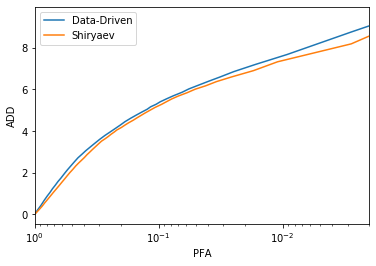

In [ ]:
plt.plot(pfa_vec,add_vec)
plt.plot(shiryaev_pfa_vec,shiryaev_add_vec)  
plt.xlim(1, 0.002) 
plt.xlabel("PFA")
plt.ylabel("ADD")
plt.xscale('log') 
plt.legend(["Data-Driven","Shiryaev"])

2) Minimax Setting

FAP Calculations

In [ ]:
# Data-Driven QCD Procedure 
test_size = 1000 # number of experiments 
h_vec = np.linspace(0.01,0.9,50) # test thresholds 
total_false_alarm_periods = np.zeros(len(h_vec)) # sum of the false alarm periods at each threshold over all experiments
for jj in range(test_size):
    if jj % 10 == 0:
        print(jj)
    # initialization for a new experiment
    t = 0 # time  
    data_prev = 0 # initialization for the data seen at time t-1
    model2.reset_states() # reset the internal RNN state for the new experiment
    alarm_flag_vec = np.zeros(len(h_vec)) # alarm flags for the new experiment
    # new experiment
    while alarm_flag_vec[-1] == 0:
        t += 1
        # observation at time t (always pre-change, no change happens at all)
        data_t = mu_pre + lambda_pre*data_prev + np.random.randn(1,1,input_dim)
        # decision statistic
        dec_stat = model2.predict(data_t) 
        dec_stat = dec_stat[0][0][0]        
        # update the alarm flags, the false alarm events, and the detection delays
        total_false_alarm_periods += t*(alarm_flag_vec == 0)*(dec_stat >= h_vec)
        alarm_flag_vec += (alarm_flag_vec == 0)*(dec_stat >= h_vec) 
        # update the previous time data
        data_prev = data_t
         
# compute the average false alarm period (fap)
fap_vec_minimax = total_false_alarm_periods/test_size

In [ ]:
fap_vec_minimax

array([1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00,
       1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00,
       1.0000000e+00, 1.0000000e+00, 1.6072000e+01, 8.1648000e+01,
       2.6168000e+02, 4.1401200e+02, 5.4579600e+02, 6.1742000e+02,
       7.3836000e+02, 8.1115200e+02, 9.0383200e+02, 1.0369760e+03,
       1.2012160e+03, 1.2821000e+03, 1.5042280e+03, 1.6990240e+03,
       2.1089120e+03, 2.1892280e+03, 2.3169440e+03, 2.4187280e+03,
       2.5396080e+03, 2.8512960e+03, 3.1134760e+03, 3.3488880e+03,
       3.5811120e+03, 3.7605920e+03, 4.2085560e+03, 4.8608080e+03,
       5.3773880e+03, 6.1514880e+03, 6.7541440e+03, 7.3245120e+03,
       8.1655040e+03, 8.6952360e+03, 9.7229680e+03, 1.0494832e+04,
       1.1816460e+04, 1.3434220e+04, 1.5044312e+04, 1.7712556e+04,
       2.1754776e+04, 2.5897900e+04])

In [ ]:
# Benchmark: Modified CUSUM Algorithm
test_size = 1000 # number of experiments 
h_vec = np.linspace(0.1,8.6,50) # test thresholds
cusum_false_alarm_periods = np.zeros(len(h_vec)) # sum of the false alarm periods at each threshold over all experiments
for jj in range(test_size):
    if jj % 50 == 0:
        print(jj)
    # initialization for a new experiment
    t = 0 # time  
    data_prev = 0
    g = 0 # reset the CUSUM state for the new experiment
    cusum_flag_vec = np.zeros(len(h_vec)) # alarm flags for the new experiment
    # new experiment
    while cusum_flag_vec[-1] == 0:
        t += 1
        # observation at time t (pre-change)
        data_t = mu_pre + lambda_pre*data_prev + np.random.randn()
        # log-likelihood ratio
        LLR = (data_t - 0.5*(data_prev*(lambda_pre+lambda_post) + (mu_pre+mu_post)))*(data_prev*(lambda_post-lambda_pre) + (mu_post-mu_pre))
        # state update
        g = np.max([0, g + LLR])      
        # update the alarm flags, the false alarm events, and the detection delays
        cusum_false_alarm_periods += t*(cusum_flag_vec == 0)*(g >= h_vec)
        cusum_flag_vec += (cusum_flag_vec == 0)*(g >= h_vec) 
        # update the previous time data
        data_prev = data_t
         
# compute the average false alarm period (fap)
cusum_fap_vec = cusum_false_alarm_periods/test_size

In [ ]:
cusum_fap_vec

array([3.7200000e+00, 4.9600000e+00, 6.6440000e+00, 8.7960000e+00,
       1.1006000e+01, 1.4280000e+01, 1.7896000e+01, 2.2702000e+01,
       3.1856000e+01, 3.8544000e+01, 4.8192000e+01, 6.0086000e+01,
       7.0804000e+01, 8.7948000e+01, 1.0449400e+02, 1.2561400e+02,
       1.4279200e+02, 1.6608200e+02, 2.0951800e+02, 2.4927400e+02,
       2.9709000e+02, 3.6114800e+02, 4.2718600e+02, 5.2252600e+02,
       6.0792200e+02, 7.4404800e+02, 9.0065600e+02, 1.0776580e+03,
       1.2874140e+03, 1.5424200e+03, 1.8843280e+03, 2.1470600e+03,
       2.4894520e+03, 3.0962040e+03, 3.6082680e+03, 4.3271700e+03,
       5.1225720e+03, 6.2857240e+03, 7.6346640e+03, 9.1576620e+03,
       1.0559226e+04, 1.2429732e+04, 1.5039796e+04, 1.8166748e+04,
       2.1565548e+04, 2.6168622e+04, 3.2738714e+04, 3.8055016e+04,
       4.2795394e+04, 5.0083852e+04])

In [ ]:
# Benchmark: Modified SR Procedure
test_size = 1000 # number of experiments 
h_vec = np.linspace(0.2,9600,50)  # test thresholds
sr_false_alarm_periods = np.zeros(len(h_vec)) # sum of the false alarm periods at each threshold over all experiments
for jj in range(test_size):
    if jj % 50 == 0: 
        print(jj)
    # initialization for a new experiment
    t = 0 # time  
    data_prev = 0
    g = 0 # reset the SR state for the new experiment
    sr_flag_vec = np.zeros(len(h_vec)) # alarm flags for the new experiment
    # new experiment
    while sr_flag_vec[-1] == 0:
        t += 1
        # observation at time t (pre-change)
        data_t = mu_pre + lambda_pre*data_prev + np.random.randn()
        # likelihood ratio 
        LR = np.exp((data_t - 0.5*(data_prev*(lambda_pre+lambda_post) + (mu_pre+mu_post)))*(data_prev*(lambda_post-lambda_pre) + (mu_post-mu_pre)))
        # state update
        g = (1+g)*LR     
        # update the alarm flags, the false alarm events, and the detection delays
        sr_false_alarm_periods += t*(sr_flag_vec == 0)*(g >= h_vec)
        sr_flag_vec += (sr_flag_vec == 0)*(g >= h_vec) 
        # update the previous time data
        data_prev = data_t
         
# compute the average false alarm period (fap)
sr_fap_vec = sr_false_alarm_periods/test_size

In [ ]:
sr_fap_vec

array([1.1380000e+00, 5.1980800e+02, 1.1054940e+03, 1.7641440e+03,
       2.4092480e+03, 2.9443260e+03, 3.6111880e+03, 4.2684460e+03,
       4.9304800e+03, 5.4339800e+03, 5.9666960e+03, 6.5512360e+03,
       7.1114420e+03, 7.5827100e+03, 8.2686860e+03, 8.8902400e+03,
       9.5797000e+03, 1.0111096e+04, 1.0462240e+04, 1.0810618e+04,
       1.1273348e+04, 1.1704998e+04, 1.2502476e+04, 1.3307898e+04,
       1.4038428e+04, 1.4831830e+04, 1.5372448e+04, 1.5988160e+04,
       1.6393776e+04, 1.6928138e+04, 1.7499750e+04, 1.7966696e+04,
       1.8696636e+04, 1.9360508e+04, 1.9944396e+04, 2.0598484e+04,
       2.0802688e+04, 2.1507448e+04, 2.1953266e+04, 2.2733004e+04,
       2.3385966e+04, 2.3883108e+04, 2.4860262e+04, 2.5219138e+04,
       2.5987820e+04, 2.6371924e+04, 2.7395652e+04, 2.8189774e+04,
       2.8877128e+04, 2.9504506e+04])

Average Detection Delay Calculations (tau = 1)

In [ ]:
# Data-Driven QCD Procedure 
test_size = 10000 # number of experiments 
h_vec = np.linspace(0.01,0.9,50) # test thresholds
total_detection_delays = np.zeros(len(h_vec)) # sum of the detection delays at each threshold over all experiments
for jj in range(test_size):
    if jj % 1000 == 0:
        print(jj)
    # initialization for a new experiment
    t = 0 # time  
    data_prev = 0 # initialization for the data seen at time t-1
    model2.reset_states() # reset the internal RNN state for the new experiment
    alarm_flag_vec = np.zeros(len(h_vec)) # alarm flags for the new experiment
    # new experiment
    while alarm_flag_vec[-1] == 0:
        t += 1
        # observation at time t (always post-change, change happens at tau = 1)
        data_t = mu_post + lambda_post*data_prev + np.random.randn(1,1,input_dim)
        # decision statistic
        dec_stat = model2.predict(data_t) 
        dec_stat = dec_stat[0][0][0]        
        # update the alarm flags, the false alarm events, and the detection delays
        total_detection_delays += (t-1)*(alarm_flag_vec == 0)*(dec_stat >= h_vec)
        alarm_flag_vec += (alarm_flag_vec == 0)*(dec_stat >= h_vec) 
        # update the previous time data
        data_prev = data_t
         
# compute the average false alarm period (fap) 
add_vec_minimax = total_detection_delays/test_size

In [ ]:
add_vec_minimax 

array([0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.0075, 0.0962, 0.3993, 0.8065, 0.9874, 1.1102,
       1.2406, 1.384 , 1.5166, 1.6522, 1.7911, 1.9256, 2.0558, 2.2081,
       2.3623, 2.4969, 2.6321, 2.7817, 2.9213, 3.0469, 3.1953, 3.3248,
       3.4654, 3.5985, 3.7328, 3.8721, 3.9953, 4.1226, 4.2309, 4.3495,
       4.4664, 4.5885, 4.7057, 4.8272, 4.9601, 5.104 , 5.2725, 5.4536,
       5.6541, 5.8752])

In [ ]:
# Benchmark: Modified CUSUM Algorithm
test_size = 10000 # number of experiments 
h_vec = np.linspace(0.1,8.6,50) # test thresholds
cusum_detection_delays = np.zeros(len(h_vec)) # sum of the detection delays at each threshold over all experiments
for jj in range(test_size):
    if jj % 1000 == 0:
        print(jj)
    # initialization for a new experiment
    t = 0 # time  
    data_prev = 0
    g = 0 # reset the CUSUM state for the new experiment
    cusum_flag_vec = np.zeros(len(h_vec)) # alarm flags for the new experiment
    # new experiment
    while cusum_flag_vec[-1] == 0:
        t += 1
        # observation at time t (post-change)
        data_t = mu_post + lambda_post*data_prev + np.random.randn()
        # log-likelihood ratio
        LLR = (data_t - 0.5*(data_prev*(lambda_pre+lambda_post) + (mu_pre+mu_post)))*(data_prev*(lambda_post-lambda_pre) + (mu_post-mu_pre)) 
        # state update
        g = np.max([0, g + LLR])      
        # update the alarm flags, the false alarm events, and the detection delays
        cusum_detection_delays += (t-1)*(cusum_flag_vec == 0)*(g >= h_vec)
        cusum_flag_vec += (cusum_flag_vec == 0)*(g >= h_vec) 
        # update the previous time data
        data_prev = data_t 
         
# compute the average false alarm period (fap)
cusum_add_vec = cusum_detection_delays/test_size 

In [ ]:
cusum_add_vec

array([0.5467, 0.7009, 0.8658, 1.049 , 1.2312, 1.4251, 1.6241, 1.8225,
       2.0042, 2.1704, 2.3353, 2.4959, 2.6435, 2.7771, 2.9181, 3.045 ,
       3.1806, 3.3034, 3.4266, 3.5592, 3.6819, 3.8047, 3.9283, 4.0648,
       4.1864, 4.3173, 4.4372, 4.572 , 4.6938, 4.8242, 4.9419, 5.0584,
       5.1799, 5.3094, 5.4347, 5.5499, 5.6708, 5.789 , 5.91  , 6.0321,
       6.1506, 6.2719, 6.3795, 6.5021, 6.627 , 6.7541, 6.8687, 6.9908,
       7.1148, 7.2338])

In [ ]:
# Benchmark: Modified SR Procedure
test_size = 10000 # number of experiments 
h_vec = np.linspace(0.2,9600,50)  # test thresholds
sr_detection_delays = np.zeros(len(h_vec)) # sum of the detection delays at each threshold over all experiments
for jj in range(test_size):
    if jj % 1000 == 0:
        print(jj)
    # initialization for a new experiment
    t = 0 # time  
    data_prev = 0
    g = 0 # reset the SR state for the new experiment
    sr_flag_vec = np.zeros(len(h_vec)) # alarm flags for the new experiment
    # new experiment
    while sr_flag_vec[-1] == 0:
        t += 1
        # observation at time t (pre-change)
        data_t = mu_post + lambda_post*data_prev + np.random.randn()
        # likelihood ratio 
        LR = np.exp((data_t - 0.5*(data_prev*(lambda_pre+lambda_post) + (mu_pre+mu_post)))*(data_prev*(lambda_post-lambda_pre) + (mu_post-mu_pre)))
        # state update
        g = (1+g)*LR     
        # update the alarm flags, the false alarm events, and the detection delays
        sr_detection_delays += (t-1)*(sr_flag_vec == 0)*(g >= h_vec)
        sr_flag_vec += (sr_flag_vec == 0)*(g >= h_vec) 
        # update the previous time data
        data_prev = data_t
         
# compute the average false alarm period (fap)
sr_add_vec = sr_detection_delays/test_size

In [ ]:
sr_add_vec

array([0.0169, 4.422 , 4.9283, 5.211 , 5.4174, 5.5759, 5.7073, 5.8138,
       5.9109, 5.9901, 6.0769, 6.1365, 6.1945, 6.2462, 6.2957, 6.3412,
       6.3921, 6.4384, 6.4859, 6.5256, 6.5628, 6.5965, 6.6271, 6.6583,
       6.6848, 6.7106, 6.7375, 6.7666, 6.795 , 6.8159, 6.8353, 6.8562,
       6.8773, 6.9025, 6.9232, 6.943 , 6.9628, 6.983 , 7.0027, 7.019 ,
       7.0318, 7.049 , 7.0652, 7.0775, 7.0958, 7.1181, 7.1389, 7.1526,
       7.1656, 7.181 ])

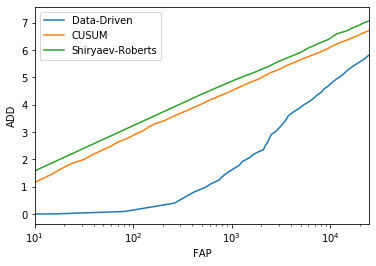

In [ ]:
plt.plot(fap_vec_minimax,add_vec_minimax)
plt.plot(cusum_fap_vec,cusum_add_vec)
plt.plot(sr_fap_vec,sr_add_vec)
plt.xlim(10,25000)
plt.xscale('log')
plt.xlabel('FAP')
plt.ylabel('ADD') 
plt.legend(["Data-Driven","CUSUM","Shiryaev-Roberts"]) 